In [77]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, train_test_split

In [78]:
white_df = pd.read_csv("./wine_quality/winequality-white.csv", delimiter=";")
white_df.shape

(4898, 12)

In [79]:
white_df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [80]:
red_df = pd.read_csv("./wine_quality/winequality-red.csv", delimiter=";")
red_df.shape

(1599, 12)

In [81]:
white_df["white wine"] = 1
red_df["white wine"] = 0

In [82]:
red_df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,white wine
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [83]:
combined_df = pd.concat([white_df, red_df])
combined_df = combined_df.sample(frac=1).reset_index(drop=True)
combined_df.shape

(6497, 13)

In [84]:
combined_df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,white wine
0,6.6,0.32,0.22,16.7,0.046,38.0,133.0,0.99790,3.22,0.67,10.4,6,1
1,6.8,0.64,0.08,9.7,0.062,26.0,142.0,0.99720,3.37,0.46,8.9,4,1
2,5.8,0.28,0.34,2.2,0.037,24.0,125.0,0.98986,3.36,0.33,12.8,8,1
3,6.6,0.42,0.13,12.8,0.044,26.0,158.0,0.99772,3.24,0.47,9.0,5,1
4,6.4,0.31,0.31,12.9,0.045,55.0,161.0,0.99546,3.02,0.59,10.2,5,1


In [85]:
combined_df.isnull().values.any()

np.False_

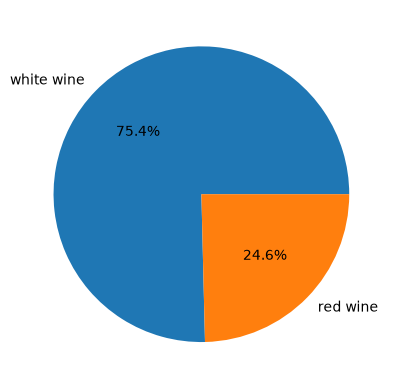

In [91]:
wine_type_values = combined_df["white wine"].value_counts().values
wine_type_labels = ["white wine", "red wine"]
plt.pie(wine_type_values, labels=wine_type_labels, autopct="%1.1f%%")
plt.show()

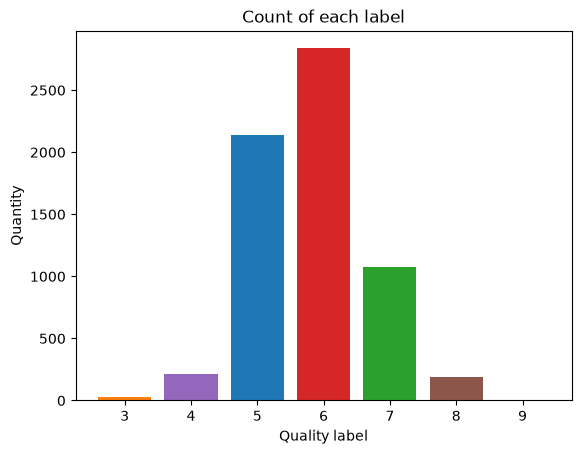

In [94]:
fig, ax = plt.subplots()
quality_values = combined_df["quality"].value_counts().values
quality_labels = combined_df["quality"].value_counts().index
bar_colours = ["tab:red", "tab:blue", "tab:green", "tab:purple", "tab:brown", "tab:orange", "tab:pink"]
ax.bar(quality_labels, quality_values, label=quality_labels, color=bar_colours)
ax.set_xlabel("Quality label")
ax.set_ylabel("Quantity")
ax.set_title("Count of each label")
plt.show()

In [95]:
combined_df["good quality"] = [0 if x < 6 else 1 for x in combined_df["quality"]]
combined_df["good quality"].value_counts(normalize=True)

good quality
1    0.633061
0    0.366939
Name: proportion, dtype: float64

In [98]:
combined_df.drop(["quality"], inplace=True, axis=1)

In [99]:
combined_df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,white wine,good quality
0,6.6,0.32,0.22,16.7,0.046,38.0,133.0,0.99790,3.22,0.67,10.4,1,1
1,6.8,0.64,0.08,9.7,0.062,26.0,142.0,0.99720,3.37,0.46,8.9,1,0
2,5.8,0.28,0.34,2.2,0.037,24.0,125.0,0.98986,3.36,0.33,12.8,1,1
3,6.6,0.42,0.13,12.8,0.044,26.0,158.0,0.99772,3.24,0.47,9.0,1,0
4,6.4,0.31,0.31,12.9,0.045,55.0,161.0,0.99546,3.02,0.59,10.2,1,0


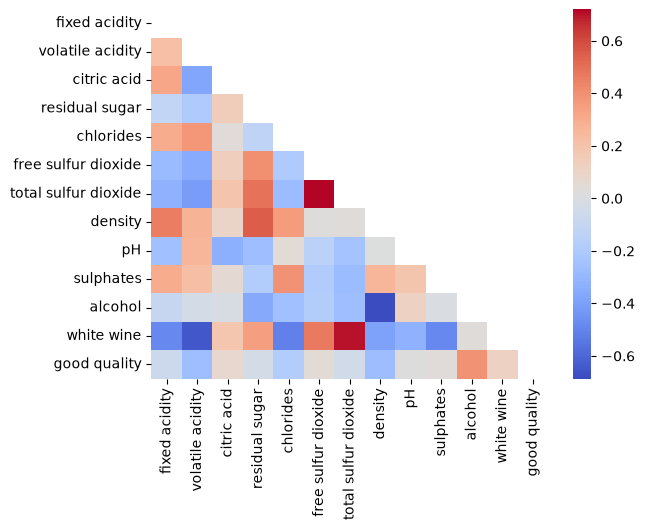

In [100]:
mask = np.triu(np.ones_like(combined_df.corr()))
data_plot = sns.heatmap(combined_df.corr(), cmap="coolwarm", mask=mask)